In [1]:
import pandas as pd

c:\Users\manoj\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# loading data

data = "../data/retail_data_interim.csv"

df = pd.read_csv(data)

In [3]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
from steps.transaction import Transaction
from steps.fp_growth import FPGrowth
from steps.association_rule import AssociationRule
from steps.final_rule import  FinalRules
from steps.save import save_
from steps.network import NetWork
from steps.engine import Engine

Transaction

In [5]:

class_transaction = Transaction(df)

basket_transaction = class_transaction.transaction_()


In [37]:
basket_transaction.head()

,Apple,Baby Food,Banana,Beef,Belt,Biscuits,Bread,Butter,Cake,Carrot,...,Spinach,Sugar,Tea,Tissue,Toilet Paper,Tomato,Toothpaste,Vitamins,Wheat Flour,Yogurt
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


FP-Growth

In [6]:
class_fpgrowth = FPGrowth()

freq_items = class_fpgrowth.freq_items_(basket_transaction,0.005)

In [7]:
print(class_fpgrowth.identified_freq())

length
2    966
1     68
Name: count, dtype: int64


In [8]:
freq_items

,support,itemsets,length
0,0.081868,frozenset({Dishwashing Liquid}),1
56,0.080864,frozenset({Chips}),1
22,0.079357,frozenset({Soda}),1
4,0.079357,frozenset({Energy Drink}),1
48,0.079357,frozenset({Cake}),1
...,...,...,...
73,0.005023,"frozenset({Pastry, Soda})",2
998,0.005023,"frozenset({Croissant, Jeans})",2
997,0.005023,"frozenset({Earphones, Jeans})",2
990,0.005023,"frozenset({Eggs, Fiction Book})",2


Association Rule

In [ ]:
class_association = AssociationRule(freq_items)

rule = class_association.applyRule_(0.11)

applied threshold is  0.11
total items:  70


Final Rules

In [14]:

final_rule = FinalRules()

apply_final_rule = final_rule.addRules(rule)

In [15]:
apply_final_rule

,antecedents,consequents,support,confidence,lift
59,Juice,Shirt,0.007534,0.115385,1.930511
58,Shirt,Juice,0.007534,0.126050,1.930511
41,Educational Book,Croissant,0.008036,0.136752,1.890788
40,Croissant,Educational Book,0.008036,0.111111,1.890788
3,Earphones,Detergent,0.009543,0.131944,1.850010
...,...,...,...,...,...
39,Mixer Grinder,Pasta,0.008036,0.110345,1.435925
48,Biscuits,Prawns,0.008036,0.112676,1.428905
66,Charger,Toilet Paper,0.007032,0.110236,1.425197
69,Educational Book,Cake,0.006529,0.111111,1.400141


In [ ]:
# save_(apply_final_rule,"pipeline_final_rules.csv")

Netword Graph

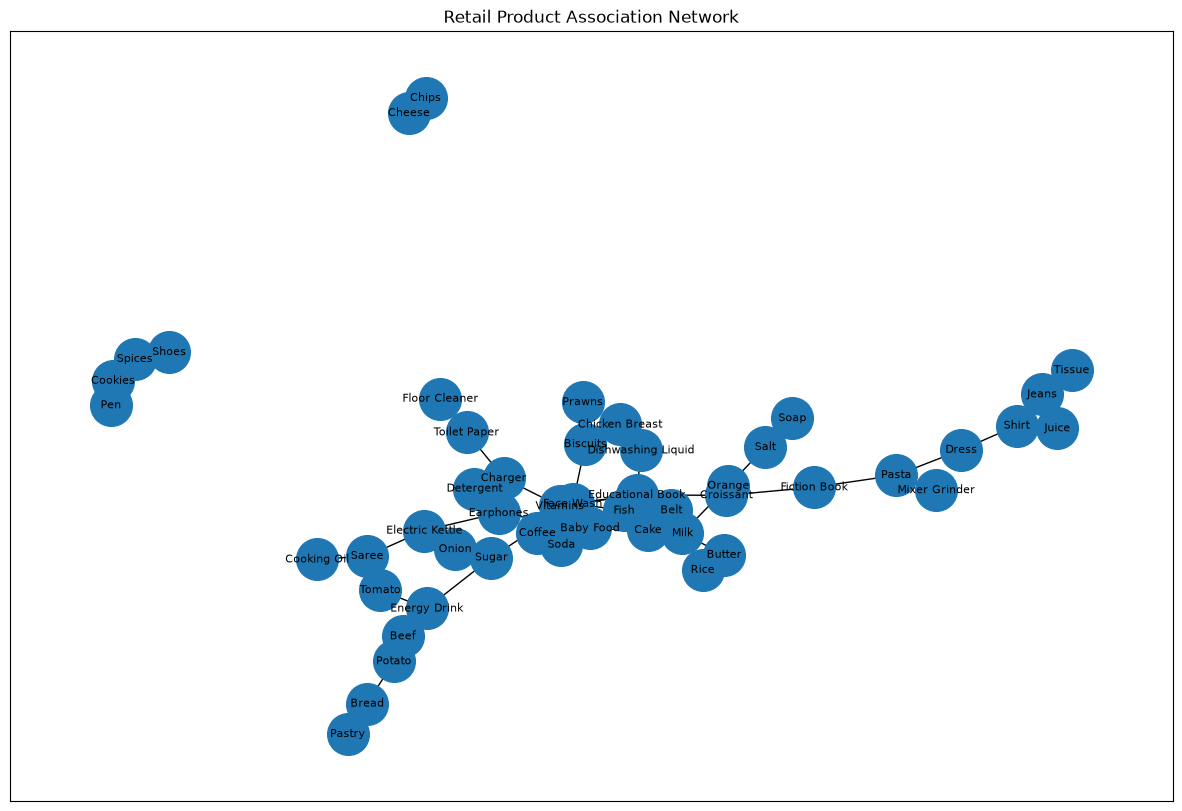

In [28]:

network = NetWork()

network.show_network_(apply_final_rule)

get_communities = network.get_shelf()

Get Shelfs

In [19]:

engine = Engine()

engine.shelf_engine_(get_communities,4)

,Shelf,Product
0,Shelf 1,Fish
1,Shelf 1,Dishwashing Liquid
2,Shelf 1,Chicken Breast
3,Shelf 1,Belt
4,Shelf 2,Face Wash
5,Shelf 2,Prawns
6,Shelf 2,Onion
7,Shelf 2,Sugar
8,Shelf 3,Biscuits
9,Shelf 4,Pastry


In [ ]:
# engine.save_list("final_shelf_items_list.csv")    # for saving final shelf items list

In [20]:
engine.get_list_()

Shelf
Shelf 1      [Fish, Dishwashing Liquid, Chicken Breast, Belt]
Shelf 10                                [Shirt, Juice, Pasta]
Shelf 11                           [Salt, Butter, Rice, Milk]
Shelf 12                                       [Orange, Soap]
Shelf 13    [Floor Cleaner, Charger, Toilet Paper, Baby Food]
Shelf 14                               [Earphones, Detergent]
Shelf 15                        [Pen, Spices, Shoes, Cookies]
Shelf 16                                      [Chips, Cheese]
Shelf 2                     [Face Wash, Prawns, Onion, Sugar]
Shelf 3                                            [Biscuits]
Shelf 4        [Pastry, Tomato, Cooking Oil, Electric Kettle]
Shelf 5                   [Saree, Energy Drink, Beef, Potato]
Shelf 6                                               [Bread]
Shelf 7     [Educational Book, Soda, Fiction Book, Croissant]
Shelf 8                              [Cake, Coffee, Vitamins]
Shelf 9                 [Mixer Grinder, Tissue, Dress, Jeans]
Na